## Raw data location, cleaning and processing

### How does an estuary microbial community responds to disturbances and what environmental factors drive the response?

In [1]:
import sys
import os

sys.path.append(os.path.abspath('..')) #utils is in the project repo
from scripts.utils import *

%matplotlib inline

In [2]:
import plotly.offline as pyo
import plotly.graph_objs as go
pyo.init_notebook_mode()

## Methods
Data formatted + cleaned for 2014-2021 (2022 to come)
- Ran through the pipeline splitting 16S/18S
> Focus on bacteria/archaea and chloroplast
- We have 5 depths
> Vertical connectivity

#### What are the observable physical/chemical disturbances based off metadata, and define their scale.
Environmental metadata

**I think we should focus on 1 or 2 disturbances first: the most frequent or impactful events**

Known list of events:
- Tropical storm Arthur Jul2014 (Cat1, heavy rains)
- Hurricane Matthew Oct2016 (Heavy rains)
- Post-tropical storm Gert Sept2017 
- Hurricane Dorian Sep2019 (Category 2)
- Post-tropical storm Teddy Sep2020 (+- Rains)
- Hurricane Fiona Sep2022 (Cat2 5x more damage than Dorian)
- Extratropical cyclone Lee Sep 2023 (Mild rains and winds)

Disturbances via metadata
+ Plot time series of each variable of interest
+ Identify large deviations
> Storm-associated changes only

#### EDA of metadata

- large temperature shifts (heatwaves, cold snaps)

In [2]:
all_depths('temperature')

- extreme salinity shifts
    - may 2017 drop

In [3]:
all_depths('sigmaTheta', hidden=[10]) #salinity, Salinity, sigmaTheta

- nutrient spikes or eutrophication events?
    - Sept 2019/2017: Nitrite spike in depth 60 post-Dorian post-Gert, not at 1m as expected after fall bloom
    - Nov 2019 (nitrification at 60m), and Nov 2021 N2O peaks (Martha)

In [4]:
all_depths('Nitrite', hidden=[60]) #temperature, Nitrate, Nitrite, Phosphate, Silicate, Ammonia, Salinity

In [5]:
make_int_plot('Nitrite',5)

/Users/Diana/Documents/escuela/phd/ch2/bedfordbasinTS/functions.py:350: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



- storms, heavy rainfall
    - I need to download the rainfall data from Env. Canada
> If we are interested in storms, this is probably what I need and identify major rainfall as disturbances

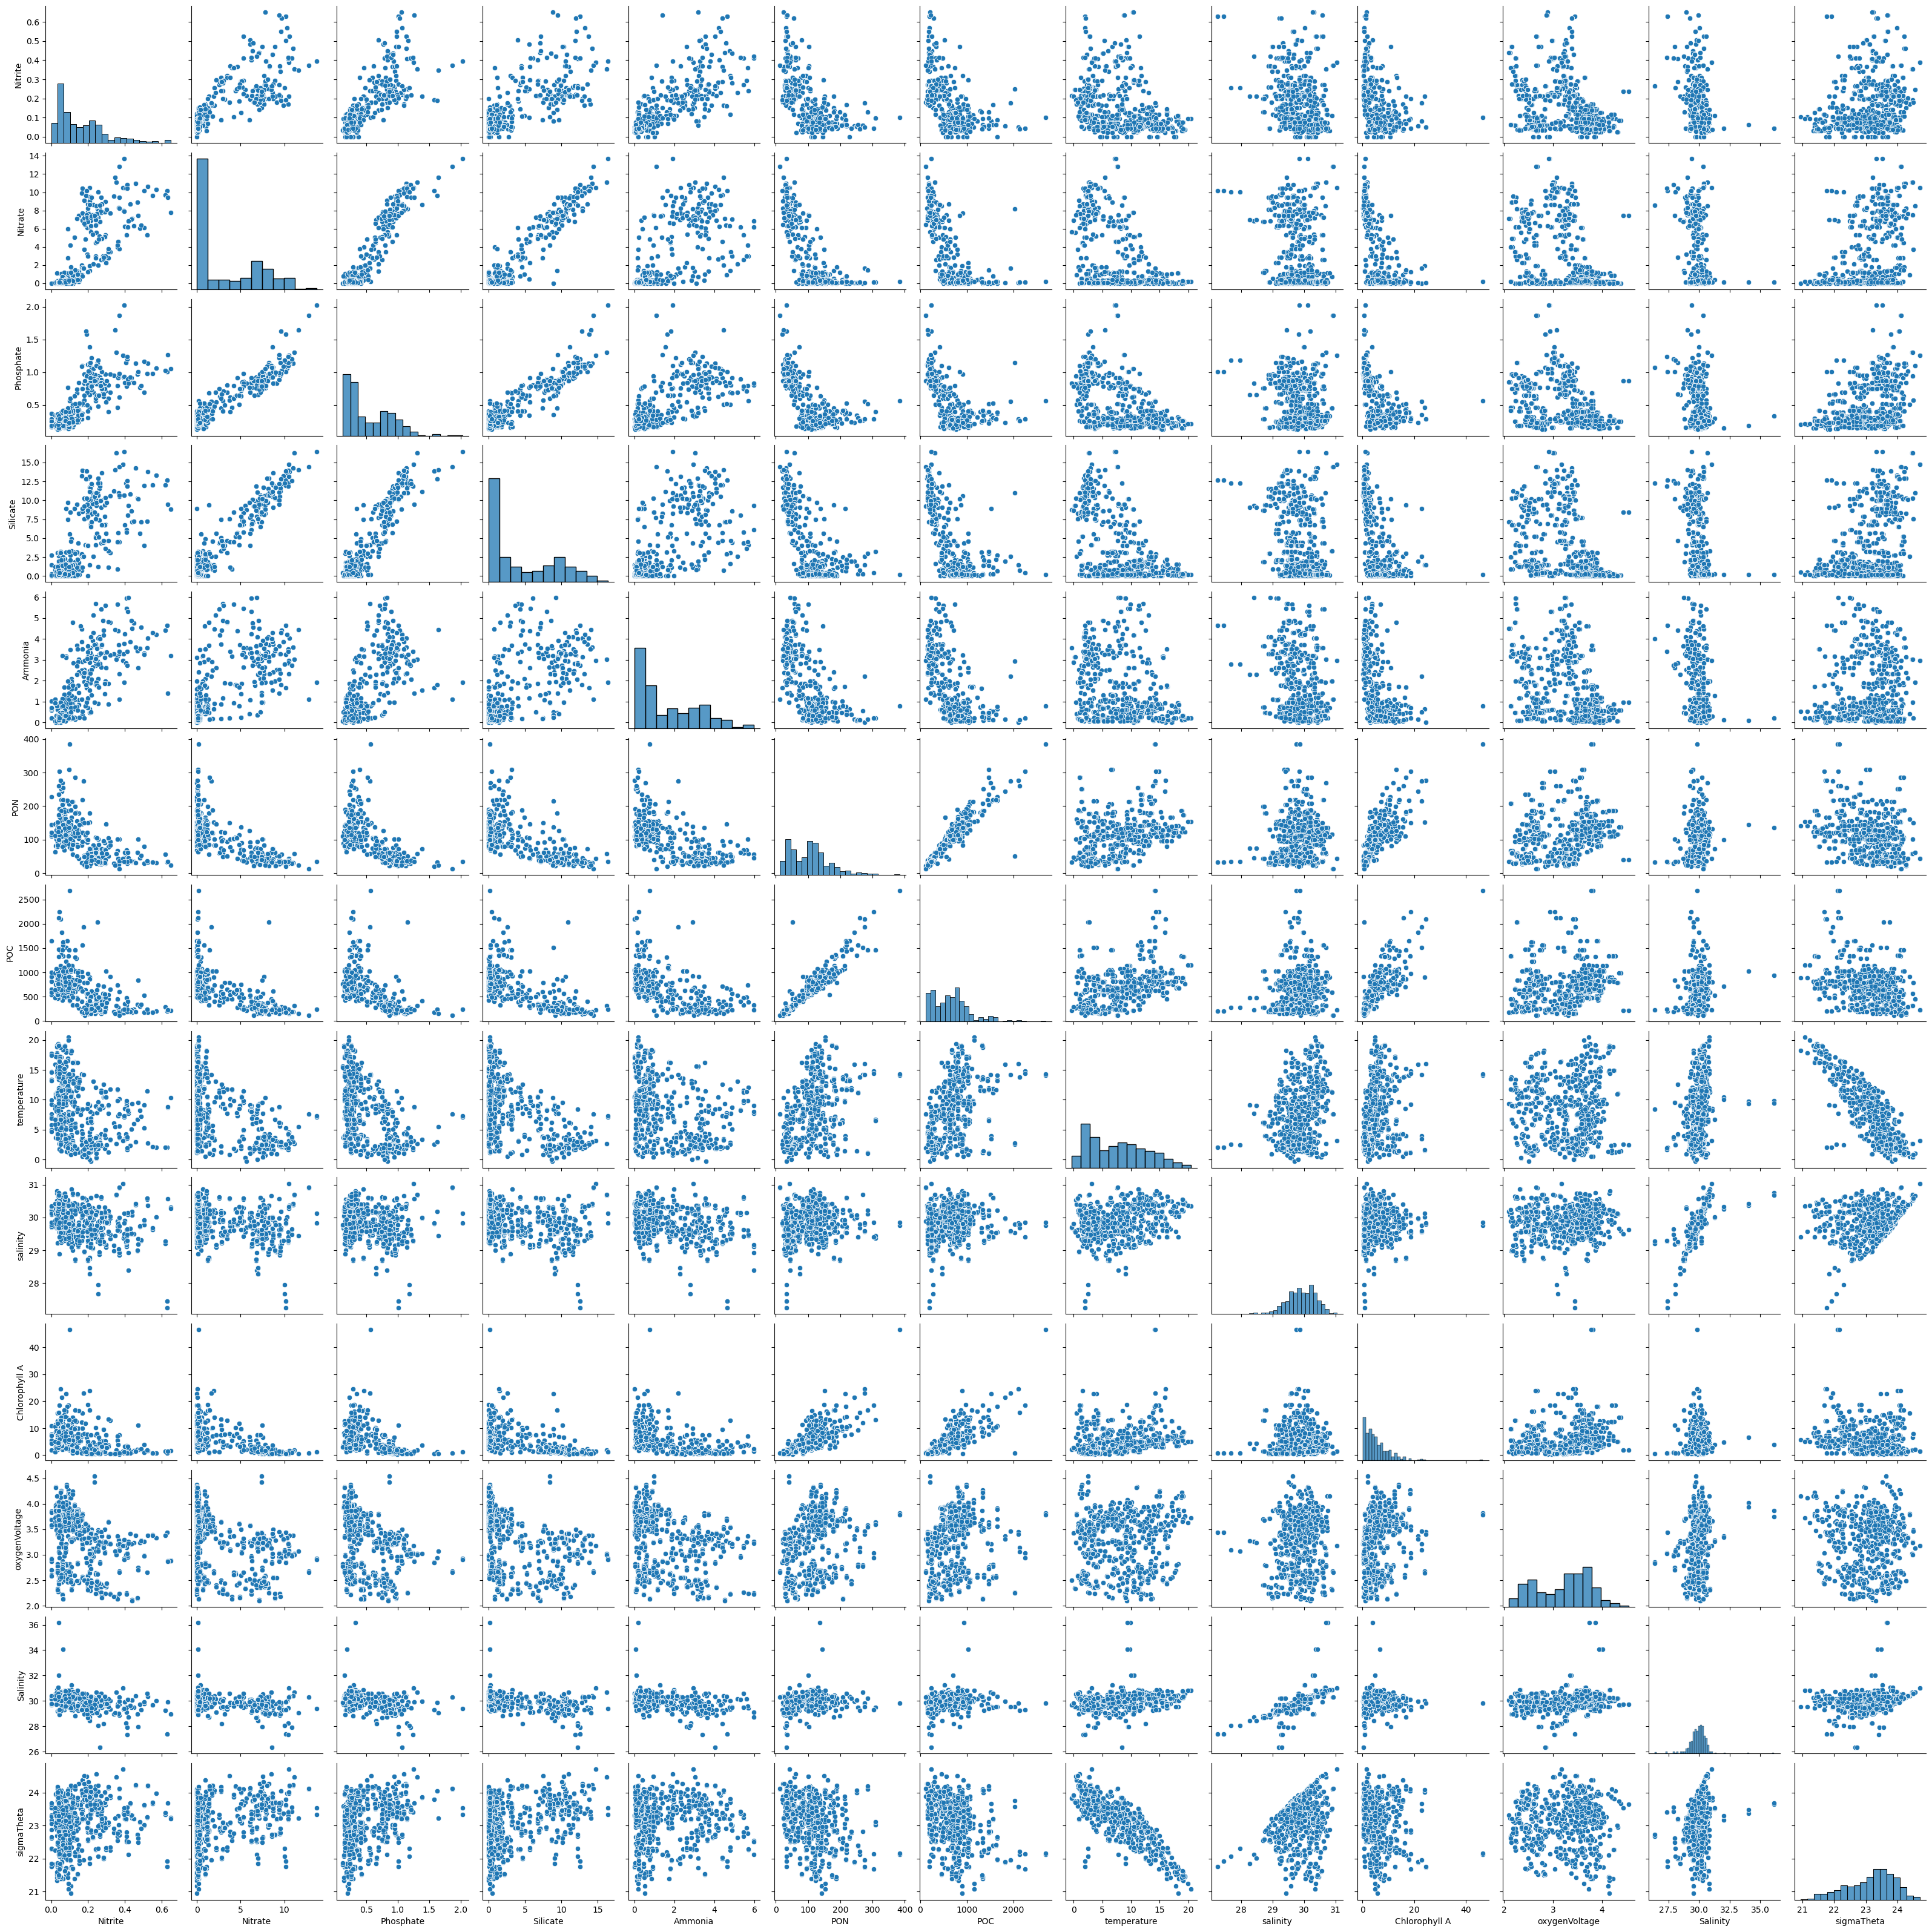

In [ ]:
correlation_pairplot(lab_md, selected_columns, 5)
#PON, POC correlated

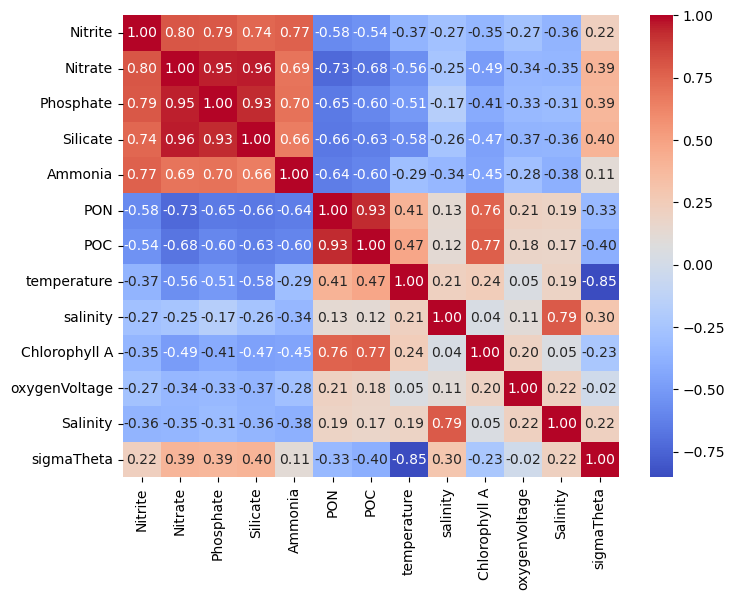

In [9]:
lab_md = pd.read_csv("/Users/Diana/Downloads/allmetadata_edit_Oct17_2024(allmetadata).csv")
selected_columns=['Nitrite', 'Nitrate', 'Phosphate', 'Silicate', 'Ammonia','PON', 'POC','temperature', 'salinity', 'Chlorophyll A', 'oxygenVoltage', 'Salinity', 'sigmaTheta']
pca_result, corr_matrix = pca_and_correlation_analysis(lab_md, selected_columns, n_components=3, plot=True, depth=5)

Nutrients are correlated (Nitrite, Nitrate, Phosphate, Silicate, Ammonia)

Look directly for community shifts:
- Plot alpha diversity over time
- Plot ordination plots
- Indicator species

#### Describe the temporal succession of the community to disturbances
Years: 2014-2022

#### Can we identify disturbances based off changes in the microbial community (i.e. does change in community = disturbance?)


#### Did the community change in response to disturbances?

How much time for the community to revert? (Disturbances in september 2019-2022)
Focus on which type of disturbances? precipitations
How do we define the scope?

#### Metadata __md__ is formatted. It contains 38 columns.
__md__ is the lab's metadata for sampling, extraction and sequencing. \
__dfo_md__ is BBMP remote sensing data (salinity, pH, temperature, density..) \
__bio_niskin__ is nutrient data \
Format __bio_niskin__ data to merge with __md__. __bio_niskin__ is 32 columns, including year, month, day, and depth. __dfo_md__ also has 32 columns, including year_time, month_time, day_time. To merge these data with __md__, we will change the time stamps columns to the same name, and generate a time_string column.

In [3]:
md = load_df()
#typo in names
md.replace({'BB18. 50AL': 'BB18.50AL',
            'BB18..16CL': 'BB18.16CL',
           'BB18.13.BS': 'BB18.13BS',
           'BB18.13.CL': 'BB18.13CL',
           'BB18.13CDS': 'BB18.13DS'}, inplace=True)
all_md = reformat_md(md)

/Users/Diana/Documents/escuela/phd/ch2/bb_data/2014/METADATA.txt
/Users/Diana/Documents/escuela/phd/ch2/bb_data/2022/METADATA.txt
/Users/Diana/Documents/escuela/phd/ch2/bb_data/2015/METADATA.txt
/Users/Diana/Documents/escuela/phd/ch2/bb_data/2017/METADATA.txt
/Users/Diana/Documents/escuela/phd/ch2/bb_data/2019/METADATA.txt
/Users/Diana/Documents/escuela/phd/ch2/bb_data/2021/METADATA.txt
/Users/Diana/Documents/escuela/phd/ch2/bb_data/2020/METADATA.txt
/Users/Diana/Documents/escuela/phd/ch2/bb_data/2018/METADATA.txt
/Users/Diana/Documents/escuela/phd/ch2/bb_data/2016/METADATA.txt


/Users/Diana/Documents/escuela/phd/ch2/bedfordbasinTS/scripts/utils.py:557: UserWarning:

You are merging on int and float columns where the float values are not equal to their int representation.

/Users/Diana/Documents/escuela/phd/ch2/bedfordbasinTS/scripts/utils.py:558: UserWarning:

You are merging on int and float columns where the float values are not equal to their int representation.

/Users/Diana/Documents/escuela/phd/ch2/bedfordbasinTS/scripts/utils.py:562: UserWarning:

You are merging on int and float columns where the float values are not equal to their int representation.

/Users/Diana/Documents/escuela/phd/ch2/bedfordbasinTS/scripts/utils.py:571: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



In [4]:
df = consolidate_tables(year=all)
df['sample_name'] = df['sample_name'].replace({'\.0':'.'}, regex=True)
#some sample names included the lane number
df['nouveau']=df['sample_name'].str.split('.').str[:2].str.join('.')

Found all yearly tables
Successfully saved all tables.


In [12]:
#all_md = reformat_md(md)

/Users/Diana/Documents/escuela/phd/ch2/bedfordbasinTS/functions.py:557: UserWarning:

You are merging on int and float columns where the float values are not equal to their int representation.

/Users/Diana/Documents/escuela/phd/ch2/bedfordbasinTS/functions.py:558: UserWarning:

You are merging on int and float columns where the float values are not equal to their int representation.

/Users/Diana/Documents/escuela/phd/ch2/bedfordbasinTS/functions.py:562: UserWarning:

You are merging on int and float columns where the float values are not equal to their int representation.

/Users/Diana/Documents/escuela/phd/ch2/bedfordbasinTS/functions.py:571: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



In [5]:
tables = df[['nouveau', 'feature_id', 'feature_frequency']].copy()
tables.rename(columns={'nouveau':'sample_name'}, inplace=True)

#all_md['sampleid'] = all_md['sampleid'].str.replace('_', '.')

From March 25, change in the METADATA file; use the file generated by the LAB (Ella, Martha, Becca)

In [6]:
os.chdir("/Users/Diana/Documents/escuela/phd/ch2/bedfordbasinTS")
bbmp_updated = pd.read_csv("data/BBMP_all_enviro_and_DNA.csv")

problematique = ['BB17.28B', 'BB19.a35BS','BB19.a35CS', 'BB21.16AL', 'BB18.13.BS','BB18.13.CL', 'BB18.13CDS', 'BB18.45ALb', 'BB18.45ASb', 'BB18.45BLb', 'BB18.45BSb', 'BB18.45CLb', 'BB18.45CSb','BB18.45DLb', 'BB18.45DSb', 'BB16.12A', 'BB16.12B', 'BB16.12C','BB16.12D'] #anything after week 32 in year 2021 #weeks 12 to 37 are missing from 2020 #BB17 _ 28B is missing; no notes in the metadata file #BB19 a35BS and CS were accidently combined #no idea why BB21-16AL is missing #all the BB18 45__b were extracted by accident #BB16 week 12 no samples

In [7]:
depth_num = {
    "A": 1,
    "B": 5,
    "C": 10,
    "D": 60,
    "E": 30
}

In [8]:
tables["year"] = '20' + tables["sample_name"].str.extract(r'BB(\d{2})(?=\.)')

In [9]:
df = tables[tables.feature_frequency != 0]

df["size_code"] = df["sample_name"].str.extract(r'[1-9][0-9]?[A-E]([L-S])')
df["size_code"] = df["size_code"].fillna('W')
df["depth_code"] = df["sample_name"].str.extract(r'[1-9][0-9]?([A-E])')
df['depth']= df['depth_code'].map(depth_num)
df["weekn"] = df["sample_name"].str.extract(r'\.([1-9][0-9]?)[A-E]')
df['weekn'] = pd.to_numeric(df['weekn'])
df['depth'] = pd.to_numeric(df['depth'])

df['Total'] = df['feature_frequency'].groupby(df['sample_name']).transform('sum')
df['ratio'] = df['feature_frequency']/df['Total']
df['nASVs'] = df['feature_id'].groupby(df['sample_name']).transform('count')
df['weekdepth'] = df["weekn"].astype(str) + df["depth"].astype(str)
df['avg'] = df['nASVs'].groupby(df['weekdepth']).transform('mean')
df['diff'] = df['nASVs'] - df['avg']

/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_3197/2924890885.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_3197/2924890885.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_3197/2924890885.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

In [10]:
merged=df.rename(columns={"sample_name": "sampleid"})

In [11]:
dnaconc = md[['sampleid', '[DNA]ng/uL']].copy()

In [12]:
dfinal = merged.merge(dnaconc, on="sampleid", how = 'left')

In [13]:
separated = pick_metadata(dfinal)

Appended all taxonomies to taxos
Saved separated by metadata dataframe.


In [14]:
separated

,sampleid,feature_id,feature_frequency,year,size_code,depth_code,depth,weekn,Total,ratio,nASVs,weekdepth,avg,diff,[DNA]ng/uL,Taxon,Confidence,Domain,Phylum,Class,Order,Family,Genus,Species
0,BB14.10A,df29deb0aff9e983f503e7471e71f4ec,3295.0,2014,W,A,1,10.0,30101.0,0.109465,292,10.01,347.243346,-55.243346,4.5,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.945295,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,g__Sulfitobacter,Unassigned
1,BB14.10B,df29deb0aff9e983f503e7471e71f4ec,4254.0,2014,W,B,5,10.0,27296.0,0.155847,285,10.05,320.359042,-35.359042,3.8,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.945295,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,g__Sulfitobacter,Unassigned
2,BB14.10C,df29deb0aff9e983f503e7471e71f4ec,3931.0,2014,W,C,10,10.0,22612.0,0.173846,256,10.010,304.737695,-48.737695,2.9,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.945295,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,g__Sulfitobacter,Unassigned
3,BB14.10D,df29deb0aff9e983f503e7471e71f4ec,654.0,2014,W,D,60,10.0,22063.0,0.029642,364,10.060,420.329776,-56.329776,3.7,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.945295,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,g__Sulfitobacter,Unassigned
4,BB14.11A,df29deb0aff9e983f503e7471e71f4ec,585.0,2014,W,A,1,11.0,5771.0,0.101369,123,11.01,303.271335,-180.271335,3.4,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.945295,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,g__Sulfitobacter,Unassigned
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656208,BB16.51A,c8c7844e0054e3c5c4e806c7e002fd67,1.0,2016,W,A,1,51.0,72687.0,0.000014,949,51.01,609.610425,339.389575,14.3,d__Bacteria; p__Firmicutes; c__Clostridia; o__...,0.964142,d__Bacteria,p__Firmicutes,c__Clostridia,o__Lachnospirales,f__Lachnospiraceae,g__Blautia,Unassigned
656209,BB16.51A,798d78f37dc777bf25d384de54157806,1.0,2016,W,A,1,51.0,72687.0,0.000014,949,51.01,609.610425,339.389575,14.3,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.740310,d__Bacteria,p__Proteobacteria,c__Gammaproteobacteria,o__Aeromonadales,f__Aeromonadaceae,g__Aeromonas,Unassigned
656210,BB16.51D,533452b626d38498d9846e0c614206c0,1.0,2016,W,D,60,51.0,68282.0,0.000015,746,51.060,509.423419,236.576581,18.3,NaN,NaN,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned
656211,BB16.51D,c7c37ee82988c77d5ac0e4e14c907c6a,1.0,2016,W,D,60,51.0,68282.0,0.000015,746,51.060,509.423419,236.576581,18.3,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.999973,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Sphingomonadales,f__Sphingomonadaceae,Unassigned,Unassigned


In [17]:
separated["year"] = '20' + separated["sampleid"].str.extract(r'BB(\d{2})(?=\.)')
separated["depth_code"] = separated["sampleid"].str.extract(r'[1-9][0-9]?([A-E])')
separated['depth']= separated['depth_code'].map(depth_num)
separated["size_code"] = separated["sampleid"].str.extract(r'[1-9][0-9]?[A-E]([L-S])')
separated["size_code"] = separated["size_code"].fillna('W')
separated["weekn"] = separated["sampleid"].str.extract(r'\.([1-9][0-9]?)[A-E]')
separated['weekn'] = pd.to_numeric(separated['weekn'])
separated['depth'] = pd.to_numeric(separated['depth'])


In [73]:
rarefied_df = repeat_rarefy_df(newseparated, sampling_depth=5000, repeat_times=100, random_state=42)

Removed 329 samples below the rarefaction depth of 5000.


In [75]:
rarefied_df.to_csv('rarefied_5000.csv')

In [77]:
dfm = rarefied_df.melt(ignore_index=False).reset_index()

In [79]:
dfm= dfm[dfm['value'] != 0]

In [82]:
dfm = dfm.rename(columns={"index":"sampleid", "value":"rarefied_count"})

In [88]:
dfm = dfm.rename(columns={"rarefied_count":"feature_frequency"})

In [98]:
def getinfo(df):
    df["size_code"] = df["sampleid"].str.extract(r'[1-9][0-9]?[A-E]([L-S])')
    df["size_code"] = df["size_code"].fillna('W')
    df["depth_code"] = df["sampleid"].str.extract(r'[1-9][0-9]?([A-E])')
    df['depth']= df['depth_code'].map(depth_num)
    df["weekn"] = df["sampleid"].str.extract(r'\.([1-9][0-9]?)[A-E]')
    df['weekn'] = pd.to_numeric(df['weekn'])
    df['depth'] = pd.to_numeric(df['depth'])

    df['Total'] = df['feature_frequency'].groupby(df['sampleid']).transform('sum')
    df['ratio'] = df['feature_frequency']/df['Total']
    df['nASVs'] = df['feature_id'].groupby(df['sampleid']).transform('count')
    df['weekdepth'] = df["weekn"].astype(str) + df["depth"].astype(str)
    df['avg'] = df['nASVs'].groupby(df['weekdepth']).transform('mean')
    df['diff'] = df['nASVs'] - df['avg']
    
    df["weekn"] = df["sampleid"].str.extract(r'\.([1-9][0-9]?)[A-E]')
    df["year"] = '20' + df["sampleid"].str.extract(r'BB(\d{2})(?=\.)')
    df['datetime'] = pd.to_datetime(
    df['year'].astype(str) + '-W' + df['weekn'].astype(int).astype(str) + '-1',
    format='%Y-W%W-%w')
    
    return df

In [99]:
newdf = getinfo(dfm)

In [ ]:
#newseparated = make_defract(all_md, separated)

In [18]:
del df

In [19]:
def make_news_memory_efficient(separated):
    
    # Convert key columns to categorical to save memory
    for col in ['size_code', 'weekn', 'depth']:
        if separated[col].dtype != 'category':
            separated[col] = separated[col].astype('category')
    
    # Filter rows that are used in subsequent operations and drop unwanted columns early
    mask = ~separated['size_code'].isin(["W", "P"])
    sep_SL = separated.loc[mask].copy()
    
    # Compute the total DNA sum per group; use in-place assignment to save memory
    sep_SL['[DNAt]'] = sep_SL.groupby(['weekn', 'depth'], observed=True)['[DNA]ng/uL'].transform('sum')
    sep_SL['DNApr'] = sep_SL['[DNA]ng/uL'] / sep_SL['[DNAt]']
    
    # Prepare a minimal lookup DataFrame for merging; drop duplicates immediately
    merge_df = sep_SL[['sampleid', 'DNApr', '[DNAt]']].drop_duplicates()
    
    # Free memory from sep_SL if not needed further
    del sep_SL
    
    # Merge back with the original DataFrame using a lightweight lookup table
    sepSLRA = separated.merge(merge_df, on='sampleid', how='left')
    
    # Drop rows not needed and filter further in place
    sepSLRA = sepSLRA.loc[~sepSLRA['size_code'].isin(["W", "P"])].copy()
    
    # Compute corrected feature frequency with groupby, then drop the intermediate column
    sepSLRA['Newfeature_frequency'] = sepSLRA['feature_frequency'] * sepSLRA['DNApr']
    sepSLRA['Newff'] = sepSLRA.groupby(['feature_id', 'weekn', 'depth'], observed=True)['Newfeature_frequency'].transform('sum')
    
    # Update sampleid and set size_code in one step
    sepSLRA['sampleid'] = "BB22." + sepSLRA['weekn'].astype(str) + sepSLRA['depth_code'] + "SL"
    sepSLRA['size_code'] = 'SL'
    
    # Drop unneeded columns early
    cols_to_drop = ['feature_frequency', 'Total', 'ratio', 'nASVs', 'weekdepth', 'avg',
                    'diff', '[DNA]ng/uL', 'Newfeature_frequency']
    sepSLRA.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    sepSLRA.rename(columns={'Newff': 'feature_frequency'}, inplace=True)
    sepSLRA.drop_duplicates(inplace=True)
    
    # Calculate totals and ratios in place
    sepSLRA['Total'] = sepSLRA.groupby('sampleid', observed=True)['feature_frequency'].transform('sum')
    sepSLRA['ratio'] = sepSLRA['feature_frequency'] / sepSLRA['Total']
    sepSLRA['nASVs'] = sepSLRA.groupby('sampleid', observed=True)['feature_id'].transform('nunique')
    sepSLRA.drop_duplicates(inplace=True)
    
    # Process other groups; filtering only when needed
    sep_WO = separated.loc[separated['size_code'] == "W"].drop_duplicates().copy()
    sep_PO = separated.loc[separated['size_code'] == "P"].drop_duplicates().copy()
    sep_S  = separated.loc[separated['size_code'] == "S"].copy()
    sep_L  = separated.loc[separated['size_code'] == "L"].copy()
    
    # Reset indices without creating extra copies
    sep_WO.reset_index(drop=True, inplace=True)
    sepSLRA.reset_index(drop=True, inplace=True)
    
    # Concatenate all parts at once
    newseparated = pd.concat([sepSLRA, sep_WO, sep_PO, sep_L, sep_S], ignore_index=True)
    
    # Compute combined columns and group statistics
    newseparated['weekdepth'] = newseparated["weekn"].astype(str) + newseparated["depth"].astype(str)
    newseparated['avg'] = newseparated.groupby('weekdepth', observed=True)['nASVs'].transform('mean')
    newseparated['diff'] = newseparated['nASVs'] - newseparated['avg']
    newseparated["rank"] = newseparated.groupby("sampleid", observed=True)["ratio"].rank(method="average", ascending=False)
    newseparated["ranktot"] = newseparated['rank'] / newseparated['nASVs']
    
    # Calculate shannon diversity index per sample (assuming shannon is defined)
    diversity = newseparated.groupby('sampleid', observed=True)['feature_frequency'].apply(lambda freqs: shannon(freqs))
    newseparated['shannon_diversity'] = newseparated['sampleid'].map(diversity)
    
    # For DNA concentration in SL, compute and merge as needed
    cleaned_data = newseparated.drop_duplicates(subset=["weekn", "depth", "size_code", "[DNA]ng/uL"])
    sl_fill_values = (
        cleaned_data.loc[cleaned_data["size_code"].isin(["S", "L"])]
        .groupby(["weekn", "depth"], observed=True)["[DNA]ng/uL"]
        .sum()
        .reset_index()
    )
    sl_fill_values["size_code"] = "SL"
    
    newseparated = newseparated.merge(
        sl_fill_values,
        on=["weekn", "depth", "size_code"],
        how="left",
        suffixes=('', '_fill')
    )
    newseparated.loc[newseparated["[DNA]ng/uL"].isna(), "[DNA]ng/uL"] = newseparated.loc[newseparated["[DNA]ng/uL"].isna(), "[DNA]ng/uL_fill"]
    newseparated.drop(columns=["[DNA]ng/uL_fill"], inplace=True)
    
    return newseparated

In [20]:
newseparated = make_news_memory_efficient(separated)

In [21]:
newseparated.to_csv('newseparated.csv', index=False)

In [106]:
newseparated

,sampleid,feature_id,year,size_code,depth_code,depth,weekn,Taxon,Confidence,Domain,Phylum,Class,Order,Family,Genus,Species,DNApr,[DNAt],feature_frequency,Total,ratio,nASVs,weekdepth,avg,diff,[DNA]ng/uL,rank,ranktot,shannon_diversity,datetime
0,BB22.18ASL,75ceeaa937c64399438614ca3706cf2a,2019,SL,A,1,18,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000246,73841.5,0.156973,516.510225,0.000304,1469,18.01,869.375560,599.624440,224.1,451.0,0.307012,8.691805,2019-05-06
1,BB22.18BSL,75ceeaa937c64399438614ca3706cf2a,2019,SL,B,5,18,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000379,57206.7,3.624755,585.503798,0.006191,1308,18.05,780.497482,527.502518,161.6,30.5,0.023318,8.738391,2019-05-06
2,BB22.18BSL,75ceeaa937c64399438614ca3706cf2a,2019,SL,B,5,18,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000281,57206.7,3.624755,585.503798,0.006191,1308,18.05,780.497482,527.502518,161.6,30.5,0.023318,8.738391,2019-05-06
3,BB22.18CSL,75ceeaa937c64399438614ca3706cf2a,2019,SL,C,10,18,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000866,43297.1,2.138527,533.565232,0.004008,1002,18.010,588.251292,413.748708,143.4,64.5,0.064371,8.341248,2019-05-06
4,BB22.18CSL,75ceeaa937c64399438614ca3706cf2a,2019,SL,C,10,18,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000185,43297.1,2.138527,533.565232,0.004008,1002,18.010,588.251292,413.748708,143.4,64.5,0.064371,8.341248,2019-05-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1043136,BB18.47BS,cd1c78b74af80f29c42521cc5560532a,2018,S,B,5,47,NaN,NaN,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN,NaN,1.000000,26567.000000,0.000038,487,47.05,826.008729,-339.008729,24.2,483.5,0.992813,7.227867,2018-11-19
1043137,BB18.48AS,c6df4cd74a21372a43bf3b4a3b4e5ef8,2018,S,A,1,48,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.737806,d__Bacteria,p__Proteobacteria,c__Gammaproteobacteria,o__Enterobacterales,f__Yersiniaceae,g__Serratia,Unassigned,NaN,NaN,1.000000,44691.000000,0.000022,670,48.01,966.594962,-296.594962,25.2,666.5,0.994776,7.549046,2018-11-26
1043138,BB18.5DS,9ccbc4dd1d0b20027261de36938930e6,2018,S,D,60,5,NaN,NaN,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN,NaN,1.000000,84946.000000,0.000012,725,5.060,826.428390,-101.428390,24.2,721.0,0.994483,6.608167,2018-01-29
1043139,BB18.8DS,b79a88263ae65bbcfc700a592229c142,2018,S,D,60,8,NaN,NaN,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN,NaN,1.000000,66930.000000,0.000015,707,8.060,980.103193,-273.103193,20.7,704.0,0.995757,7.051237,2018-02-19


In [22]:
# Convert key columns to categorical to save memory
for col in ['size_code', 'weekn', 'depth']:
    if separated[col].dtype != 'category':
        separated[col] = separated[col].astype('category')

# Filter rows that are used in subsequent operations and drop unwanted columns early
mask = ~separated['size_code'].isin(["W", "P"])
sep_SL = separated.loc[mask].copy()

# Compute the total DNA sum per group; use in-place assignment to save memory
sep_SL['[DNAt]'] = sep_SL.groupby(['weekn', 'depth'], observed=True)['[DNA]ng/uL'].transform('sum')
sep_SL['DNApr'] = sep_SL['[DNA]ng/uL'] / sep_SL['[DNAt]']

# Prepare a minimal lookup DataFrame for merging; drop duplicates immediately
merge_df = sep_SL[['sampleid', 'DNApr', '[DNAt]']].drop_duplicates()

# Free memory from sep_SL if not needed further
del sep_SL

In [23]:
# Merge back with the original DataFrame using a lightweight lookup table
sepSLRA = separated.merge(merge_df, on='sampleid', how='left')

# Drop rows not needed and filter further in place
sepSLRA = sepSLRA.loc[~sepSLRA['size_code'].isin(["W", "P"])].copy()

# Compute corrected feature frequency with groupby, then drop the intermediate column
sepSLRA['Newfeature_frequency'] = sepSLRA['feature_frequency'] * sepSLRA['DNApr']
sepSLRA['Newff'] = sepSLRA.groupby(['feature_id', 'weekn', 'depth'], observed=True)['Newfeature_frequency'].transform('sum')

In [24]:
# Update sampleid and set size_code in one step
sepSLRA['sampleid'] = "BB22." + sepSLRA['weekn'].astype(str) + sepSLRA['depth_code'] + "SL"
sepSLRA['size_code'] = 'SL'

# Drop unneeded columns early
cols_to_drop = ['feature_frequency', 'Total', 'ratio', 'nASVs', 'weekdepth', 'avg',
                'diff', '[DNA]ng/uL', 'Newfeature_frequency']
sepSLRA.drop(columns=cols_to_drop, inplace=True, errors='ignore')
sepSLRA.rename(columns={'Newff': 'feature_frequency'}, inplace=True)
sepSLRA.drop_duplicates(inplace=True)

In [25]:
# Calculate totals and ratios in place
sepSLRA['Total'] = sepSLRA.groupby('sampleid', observed=True)['feature_frequency'].transform('sum')
sepSLRA['ratio'] = sepSLRA['feature_frequency'] / sepSLRA['Total']
sepSLRA['nASVs'] = sepSLRA.groupby('sampleid', observed=True)['feature_id'].transform('nunique')
sepSLRA.drop_duplicates(inplace=True)

# Process other groups; filtering only when needed
sep_WO = separated.loc[separated['size_code'] == "W"].drop_duplicates().copy()
sep_PO = separated.loc[separated['size_code'] == "P"].drop_duplicates().copy()
sep_S  = separated.loc[separated['size_code'] == "S"].copy()
sep_L  = separated.loc[separated['size_code'] == "L"].copy()

In [26]:
# Reset indices without creating extra copies
sep_WO.reset_index(drop=True, inplace=True)
sepSLRA.reset_index(drop=True, inplace=True)

# Concatenate all parts at once
newseparated = pd.concat([sepSLRA, sep_WO, sep_PO, sep_L, sep_S], ignore_index=True)

In [27]:
# Compute combined columns and group statistics
newseparated['weekdepth'] = newseparated["weekn"].astype(str) + newseparated["depth"].astype(str)
newseparated['avg'] = newseparated.groupby('weekdepth', observed=True)['nASVs'].transform('mean')
newseparated['diff'] = newseparated['nASVs'] - newseparated['avg']
newseparated["rank"] = newseparated.groupby("sampleid", observed=True)["ratio"].rank(method="average", ascending=False)
newseparated["ranktot"] = newseparated['rank'] / newseparated['nASVs']

# Calculate shannon diversity index per sample (assuming shannon is defined)
diversity = newseparated.groupby('sampleid', observed=True)['feature_frequency'].apply(lambda freqs: shannon(freqs))
newseparated['shannon_diversity'] = newseparated['sampleid'].map(diversity)

In [28]:
# For DNA concentration in SL, compute and merge as needed
cleaned_data = newseparated.drop_duplicates(subset=["weekn", "depth", "size_code", "[DNA]ng/uL"])
sl_fill_values = (
    cleaned_data.loc[cleaned_data["size_code"].isin(["S", "L"])]
    .groupby(["weekn", "depth"], observed=True)["[DNA]ng/uL"]
    .sum()
    .reset_index()
)
sl_fill_values["size_code"] = "SL"

newseparated = newseparated.merge(
    sl_fill_values,
    on=["weekn", "depth", "size_code"],
    how="left",
    suffixes=('', '_fill')
)
newseparated.loc[newseparated["[DNA]ng/uL"].isna(), "[DNA]ng/uL"] = newseparated.loc[newseparated["[DNA]ng/uL"].isna(), "[DNA]ng/uL_fill"]
newseparated.drop(columns=["[DNA]ng/uL_fill"], inplace=True)

In [29]:
newseparated

,sampleid,feature_id,year,size_code,depth_code,depth,weekn,Taxon,Confidence,Domain,Phylum,Class,Order,Family,Genus,Species,DNApr,[DNAt],feature_frequency,Total,ratio,nASVs,weekdepth,avg,diff,[DNA]ng/uL,rank,ranktot,shannon_diversity
0,BB22.18.0ASL,75ceeaa937c64399438614ca3706cf2a,2019,SL,A,1,18.0,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000246,73841.5,0.156973,516.510225,0.000304,1469,18.01,869.375560,599.624440,224.1,451.0,0.307012,8.691805
1,BB22.18.0BSL,75ceeaa937c64399438614ca3706cf2a,2019,SL,B,5,18.0,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000379,57206.7,3.624755,585.503798,0.006191,1308,18.05,780.497482,527.502518,161.6,30.5,0.023318,8.738391
2,BB22.18.0BSL,75ceeaa937c64399438614ca3706cf2a,2019,SL,B,5,18.0,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000281,57206.7,3.624755,585.503798,0.006191,1308,18.05,780.497482,527.502518,161.6,30.5,0.023318,8.738391
3,BB22.18.0CSL,75ceeaa937c64399438614ca3706cf2a,2019,SL,C,10,18.0,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000866,43297.1,2.138527,533.565232,0.004008,1002,18.010,588.251292,413.748708,143.4,64.5,0.064371,8.341248
4,BB22.18.0CSL,75ceeaa937c64399438614ca3706cf2a,2019,SL,C,10,18.0,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000185,43297.1,2.138527,533.565232,0.004008,1002,18.010,588.251292,413.748708,143.4,64.5,0.064371,8.341248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1043136,BB18.47BS,cd1c78b74af80f29c42521cc5560532a,2018,S,B,5,47.0,NaN,NaN,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN,NaN,1.000000,26567.000000,0.000038,487,47.05,826.008729,-339.008729,24.2,483.5,0.992813,7.227867
1043137,BB18.48AS,c6df4cd74a21372a43bf3b4a3b4e5ef8,2018,S,A,1,48.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.737806,d__Bacteria,p__Proteobacteria,c__Gammaproteobacteria,o__Enterobacterales,f__Yersiniaceae,g__Serratia,Unassigned,NaN,NaN,1.000000,44691.000000,0.000022,670,48.01,966.594962,-296.594962,25.2,666.5,0.994776,7.549046
1043138,BB18.5DS,9ccbc4dd1d0b20027261de36938930e6,2018,S,D,60,5.0,NaN,NaN,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN,NaN,1.000000,84946.000000,0.000012,725,5.060,826.428390,-101.428390,24.2,721.0,0.994483,6.608167
1043139,BB18.8DS,b79a88263ae65bbcfc700a592229c142,2018,S,D,60,8.0,NaN,NaN,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN,NaN,1.000000,66930.000000,0.000015,707,8.060,980.103193,-273.103193,20.7,704.0,0.995757,7.051237


In [30]:
#verify if any of the samples are empty (i.e. failed)
tiprob = separated[separated['feature_id'].isnull()]
tiprob['sampleid'].unique()

array([], dtype=object)

In [31]:
plot_adiv(newseparated, 1)

KeyError: "['month', 'day', 'season', 'time_string_x', 'time_string', 'temperature', 'Chlorophyll A', 'date'] not in index"

In [37]:
newseparated

,sampleid,feature_id,year,size_code,depth_code,depth,weekn,Taxon,Confidence,Domain,Phylum,Class,Order,Family,Genus,Species,DNApr,[DNAt],feature_frequency,Total,ratio,nASVs,weekdepth,avg,diff,[DNA]ng/uL,rank,ranktot,shannon_diversity
0,BB22.18ASL,75ceeaa937c64399438614ca3706cf2a,2019,SL,A,1,18,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000246,73841.5,0.156973,516.510225,0.000304,1469,18.01,869.375560,599.624440,224.1,451.0,0.307012,8.691805
1,BB22.18BSL,75ceeaa937c64399438614ca3706cf2a,2019,SL,B,5,18,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000379,57206.7,3.624755,585.503798,0.006191,1308,18.05,780.497482,527.502518,161.6,30.5,0.023318,8.738391
2,BB22.18BSL,75ceeaa937c64399438614ca3706cf2a,2019,SL,B,5,18,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000281,57206.7,3.624755,585.503798,0.006191,1308,18.05,780.497482,527.502518,161.6,30.5,0.023318,8.738391
3,BB22.18CSL,75ceeaa937c64399438614ca3706cf2a,2019,SL,C,10,18,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000866,43297.1,2.138527,533.565232,0.004008,1002,18.010,588.251292,413.748708,143.4,64.5,0.064371,8.341248
4,BB22.18CSL,75ceeaa937c64399438614ca3706cf2a,2019,SL,C,10,18,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000185,43297.1,2.138527,533.565232,0.004008,1002,18.010,588.251292,413.748708,143.4,64.5,0.064371,8.341248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1043136,BB18.47BS,cd1c78b74af80f29c42521cc5560532a,2018,S,B,5,47,NaN,NaN,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN,NaN,1.000000,26567.000000,0.000038,487,47.05,826.008729,-339.008729,24.2,483.5,0.992813,7.227867
1043137,BB18.48AS,c6df4cd74a21372a43bf3b4a3b4e5ef8,2018,S,A,1,48,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.737806,d__Bacteria,p__Proteobacteria,c__Gammaproteobacteria,o__Enterobacterales,f__Yersiniaceae,g__Serratia,Unassigned,NaN,NaN,1.000000,44691.000000,0.000022,670,48.01,966.594962,-296.594962,25.2,666.5,0.994776,7.549046
1043138,BB18.5DS,9ccbc4dd1d0b20027261de36938930e6,2018,S,D,60,5,NaN,NaN,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN,NaN,1.000000,84946.000000,0.000012,725,5.060,826.428390,-101.428390,24.2,721.0,0.994483,6.608167
1043139,BB18.8DS,b79a88263ae65bbcfc700a592229c142,2018,S,D,60,8,NaN,NaN,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN,NaN,1.000000,66930.000000,0.000015,707,8.060,980.103193,-273.103193,20.7,704.0,0.995757,7.051237


In [38]:
for df in [newseparated]:
    df["weekn"] = df["sampleid"].str.extract(r'\.([1-9][0-9]?)[A-E]')
    df['sampleid'] = df['sampleid'].str.replace(r'\.0', '', regex=True)
    df['sampleid'] = df['sampleid'].str.replace('.a', '.', regex=False)
    df["weekn"] = df["sampleid"].str.extract(r'\.([1-9][0-9]?)[A-E]')
    df_weekn_nan = df[df['weekn'].isna()]

In [39]:
df_weekn_nan['sampleid'].unique()

array(['BB22.nanDSL', 'BB22.nanASL', 'BB22.nanBSL', 'BB22.nanCSL'],
      dtype=object)

In [41]:
newseparated = newseparated.dropna(subset=['weekn'])

In [42]:
def adiv_plots(df_clean):
    #drop any null rows
    df_clean = df_clean.dropna(subset=['feature_id'])

    #make sure the feature asv count per sample is accurate
    df_clean['unique_feature_count'] = df_clean.groupby('sampleid')['feature_id'].transform('nunique')
    # for plotting make datetime:
    df_clean["weekn"] = df_clean["sampleid"].str.extract(r'\.([1-9][0-9]?)[A-E]')
    df_clean['datetime'] = pd.to_datetime(
        df_clean['year'].astype(str) + '-W' + df_clean['weekn'].astype(int).astype(str) + '-1',
        format='%Y-W%W-%w'
    )
    df_clean = df_clean[df_clean.depth == 1]

    ts_data = df_clean.groupby(['datetime', 'depth_code', 'size_code'])['feature_id'].nunique().reset_index(name='unique_feature_count')
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=ts_data,
        x='datetime',
        y='unique_feature_count',
        hue='size_code',
        markers=True,
        dashes=False
    )

    plt.xlabel('Date')
    plt.ylabel('nASVs')
    plt.tight_layout()
    plt.show()

In [46]:
newseparated["weekn"] = newseparated["sampleid"].str.extract(r'\.([1-9][0-9]?)[A-E]')
newseparated['datetime'] = pd.to_datetime(
    newseparated['year'].astype(str) + '-W' + newseparated['weekn'].astype(int).astype(str) + '-1',
    format='%Y-W%W-%w'
)

/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_3197/2905585323.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_3197/2905585323.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [100]:
depth1 = newdf[newdf.depth == 1]

In [103]:
depth1SL = depth1[depth1.size_code == 'W']

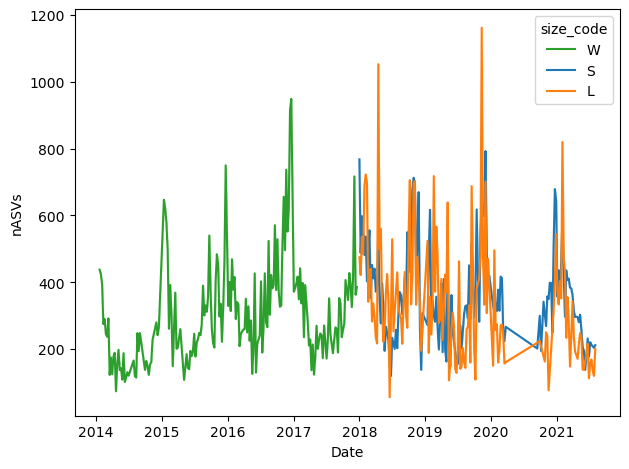

In [109]:
sizecodes = ['S', 'L', 'W', 'SL']
palette_colors = sns.color_palette()
palette_dict = {sizecode: color for sizecode, color in zip(sizecodes, palette_colors)}

sns.lineplot(
    data=depth1,
    x='datetime',
    y='nASVs',
    hue='size_code',
    markers=True,
    dashes=False,
    palette=palette_dict
)

plt.xlabel('Date')
plt.ylabel('nASVs')
plt.tight_layout()
plt.show()

In [50]:
#find the missing SL files, and why?
groups = depth1.groupby(['year', 'weekn'])

missing_SL = [
    group_name 
    for group_name, group in groups 
    if group['size_code'].isin(['S', 'L']).any() and not group['size_code'].eq('SL').any()
]

missing_SL_df = pd.DataFrame(missing_SL, columns=['year', 'weekn'])
print(missing_SL_df)

    year weekn
0   2019    27
1   2019    28
2   2019    29
3   2019    30
4   2019    31
..   ...   ...
12  2019    39
13  2019    40
14  2019    41
15  2019    42
16  2019    43

[17 rows x 2 columns]


In [61]:
separated['weekn'] = pd.to_numeric(separated['weekn'])

In [67]:
filtered = separated.loc[
    (separated['year'] == '2019'),
    ['sampleid', '[DNA]ng/uL', 'weekn']
]
filtered['weekn'].unique()

array([18., 19., 20., 21., 22., 23., 24., 26., 44., 46., 47., nan, 10.,
       11., 12., 13., 14., 15., 16., 17.,  2.,  3.,  4.,  5.,  6.,  7.,
        8.,  9., 25., 45., 48., 49., 50., 51.])

In [63]:
separated

,sampleid,feature_id,feature_frequency,year,size_code,depth_code,depth,weekn,Total,ratio,nASVs,weekdepth,avg,diff,[DNA]ng/uL,Taxon,Confidence,Domain,Phylum,Class,Order,Family,Genus,Species
0,BB14.10A,df29deb0aff9e983f503e7471e71f4ec,3295.0,2014,W,A,1,10.0,30101.0,0.109465,292,10.01,347.243346,-55.243346,4.5,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.945295,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,g__Sulfitobacter,Unassigned
1,BB14.10B,df29deb0aff9e983f503e7471e71f4ec,4254.0,2014,W,B,5,10.0,27296.0,0.155847,285,10.05,320.359042,-35.359042,3.8,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.945295,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,g__Sulfitobacter,Unassigned
2,BB14.10C,df29deb0aff9e983f503e7471e71f4ec,3931.0,2014,W,C,10,10.0,22612.0,0.173846,256,10.010,304.737695,-48.737695,2.9,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.945295,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,g__Sulfitobacter,Unassigned
3,BB14.10D,df29deb0aff9e983f503e7471e71f4ec,654.0,2014,W,D,60,10.0,22063.0,0.029642,364,10.060,420.329776,-56.329776,3.7,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.945295,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,g__Sulfitobacter,Unassigned
4,BB14.11A,df29deb0aff9e983f503e7471e71f4ec,585.0,2014,W,A,1,11.0,5771.0,0.101369,123,11.01,303.271335,-180.271335,3.4,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.945295,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,g__Sulfitobacter,Unassigned
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656208,BB16.51A,c8c7844e0054e3c5c4e806c7e002fd67,1.0,2016,W,A,1,51.0,72687.0,0.000014,949,51.01,609.610425,339.389575,14.3,d__Bacteria; p__Firmicutes; c__Clostridia; o__...,0.964142,d__Bacteria,p__Firmicutes,c__Clostridia,o__Lachnospirales,f__Lachnospiraceae,g__Blautia,Unassigned
656209,BB16.51A,798d78f37dc777bf25d384de54157806,1.0,2016,W,A,1,51.0,72687.0,0.000014,949,51.01,609.610425,339.389575,14.3,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.740310,d__Bacteria,p__Proteobacteria,c__Gammaproteobacteria,o__Aeromonadales,f__Aeromonadaceae,g__Aeromonas,Unassigned
656210,BB16.51D,533452b626d38498d9846e0c614206c0,1.0,2016,W,D,60,51.0,68282.0,0.000015,746,51.060,509.423419,236.576581,18.3,NaN,NaN,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned
656211,BB16.51D,c7c37ee82988c77d5ac0e4e14c907c6a,1.0,2016,W,D,60,51.0,68282.0,0.000015,746,51.060,509.423419,236.576581,18.3,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.999973,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Sphingomonadales,f__Sphingomonadaceae,Unassigned,Unassigned


In [56]:
newseparated

,sampleid,feature_id,year,size_code,depth_code,depth,weekn,Taxon,Confidence,Domain,Phylum,Class,Order,Family,Genus,Species,DNApr,[DNAt],feature_frequency,Total,ratio,nASVs,weekdepth,avg,diff,[DNA]ng/uL,rank,ranktot,shannon_diversity,datetime
0,BB22.18ASL,75ceeaa937c64399438614ca3706cf2a,2019,SL,A,1,18,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000246,73841.5,0.156973,516.510225,0.000304,1469,18.01,869.375560,599.624440,224.1,451.0,0.307012,8.691805,2019-05-06
1,BB22.18BSL,75ceeaa937c64399438614ca3706cf2a,2019,SL,B,5,18,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000379,57206.7,3.624755,585.503798,0.006191,1308,18.05,780.497482,527.502518,161.6,30.5,0.023318,8.738391,2019-05-06
2,BB22.18BSL,75ceeaa937c64399438614ca3706cf2a,2019,SL,B,5,18,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000281,57206.7,3.624755,585.503798,0.006191,1308,18.05,780.497482,527.502518,161.6,30.5,0.023318,8.738391,2019-05-06
3,BB22.18CSL,75ceeaa937c64399438614ca3706cf2a,2019,SL,C,10,18,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000866,43297.1,2.138527,533.565232,0.004008,1002,18.010,588.251292,413.748708,143.4,64.5,0.064371,8.341248,2019-05-06
4,BB22.18CSL,75ceeaa937c64399438614ca3706cf2a,2019,SL,C,10,18,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.000000,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis,0.000185,43297.1,2.138527,533.565232,0.004008,1002,18.010,588.251292,413.748708,143.4,64.5,0.064371,8.341248,2019-05-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1043136,BB18.47BS,cd1c78b74af80f29c42521cc5560532a,2018,S,B,5,47,NaN,NaN,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN,NaN,1.000000,26567.000000,0.000038,487,47.05,826.008729,-339.008729,24.2,483.5,0.992813,7.227867,2018-11-19
1043137,BB18.48AS,c6df4cd74a21372a43bf3b4a3b4e5ef8,2018,S,A,1,48,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.737806,d__Bacteria,p__Proteobacteria,c__Gammaproteobacteria,o__Enterobacterales,f__Yersiniaceae,g__Serratia,Unassigned,NaN,NaN,1.000000,44691.000000,0.000022,670,48.01,966.594962,-296.594962,25.2,666.5,0.994776,7.549046,2018-11-26
1043138,BB18.5DS,9ccbc4dd1d0b20027261de36938930e6,2018,S,D,60,5,NaN,NaN,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN,NaN,1.000000,84946.000000,0.000012,725,5.060,826.428390,-101.428390,24.2,721.0,0.994483,6.608167,2018-01-29
1043139,BB18.8DS,b79a88263ae65bbcfc700a592229c142,2018,S,D,60,8,NaN,NaN,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,NaN,NaN,1.000000,66930.000000,0.000015,707,8.060,980.103193,-273.103193,20.7,704.0,0.995757,7.051237,2018-02-19


In [45]:
newseparated.loc[newseparated['nASVs'].isna(), 'sampleid']

Series([], Name: sampleid, dtype: object)

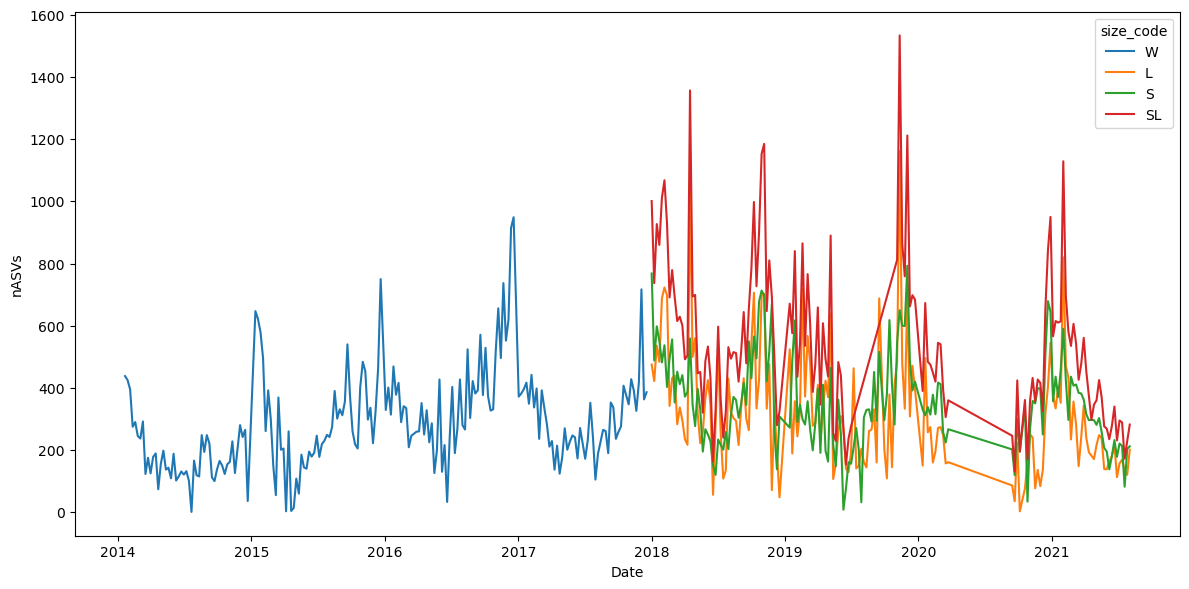

In [43]:
adiv_plots(newseparated)

In [ ]:
def repeat_rarefaction(df, sample_col='sampleid', feature_col='feature_id', count_col='feature_frequency', depth=20000, repeats=100, random_state=None):
    """
    Perform repeat-rarefaction on a long-format DataFrame.
    
    Parameters:
      df: long-format DataFrame.
      sample_col: column name for sample IDs.
      feature_col: column name for feature IDs.
      count_col: column name for counts.
      depth: rarefaction depth.
      repeats: number of rarefaction iterations.
      random_state: optional random seed.
      
    Returns:
      A DataFrame of the average rarefied counts (samples x features) across repeats.
    """
    df_wide = df.pivot_table(index=sample_col, columns=feature_col, values=count_col, fill_value=0)
    
    all_reps = []
    for i in range(repeats):
        # Optionally vary the random seed for each repeat.
        rep = df_wide.apply(lambda row: rarefy_sample(row.values, depth, random_state=(random_state+i if random_state is not None else None)), axis=1)
        all_reps.append(rep)
    
    # Convert each replicate (a DataFrame) into a list and then average across replicates.
    rep_dfs = [pd.DataFrame(list(rep), index=df_wide.index, columns=df_wide.columns) for rep in all_reps]
    mean_rarefied = sum(rep_dfs) / repeats
    return mean_rarefied

# Example usage:
# mean_rarefied_df = repeat_rarefaction(your_df, sample_col='sampleid', feature_col='feature_id',
#                                       count_col='feature_frequency', depth=20000, repeats=100, random_state=42)

In [407]:
df_y = df_clean[df_clean['year']== '2019']
#df_y = df_y[df_y['size_code']== 'S']
#df_y = df_y[df_y['depth_code']== 'A']

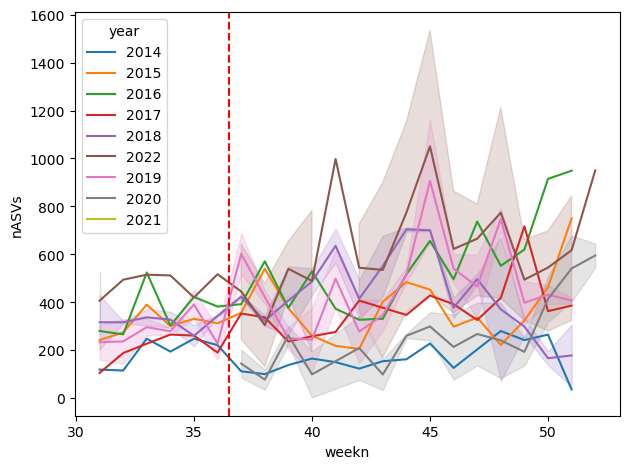

In [427]:
df_clean["weekn"] = pd.to_numeric(df_clean["weekn"])
df_y = df_clean[df_clean['weekn'] > 30]
## ADD REPEAT RAREFY STEP!
ts_data = df_y.groupby(['datetime', 'year', 'weekn', 'depth_code', 'size_code'])['feature_id'].nunique().reset_index(name='unique_feature_count')
sns.lineplot(
    data=ts_data,
    x='weekn',
    y='unique_feature_count',
    hue='year'
)

plt.ylabel('nASVs')
plt.axvline(x=36.5, color='r', linestyle='--')
plt.tight_layout()
plt.show()

In [307]:
df_clean["year"] = '20' + df_clean["sampleid"].str.extract(r'BB(\d{2})(?=\.)')
df_clean["depth_code"] = df_clean["sampleid"].str.extract(r'[1-9][0-9]?([A-E])')
df_clean['depth']= df_clean['depth_code'].map(depth_num)

In [171]:
from skbio.stats.composition import multiplicative_replacement, clr
from skbio.stats.distance import DistanceMatrix
from scipy.spatial.distance import pdist, squareform

In [402]:
df_y = df_clean[df_clean['year']== '2019']
df_y = df_y[df_y['size_code']== 'L']
df_y = df_y[df_y['depth_code']== 'A']

In [298]:
#first move your df to samples x features (filled with f frequency)
df_wide = df_y.pivot_table(
    index='sampleid',
    columns='feature_id',
    values='feature_frequency',
    fill_value=0
)

In [299]:
#extract the data for CLR transformation
data = df_wide.values
#add value to 0 for transformation
data_replaced = multiplicative_replacement(data)

#transform the data
data_clr = clr(data_replaced)

#this the new data in a clrtransformation
df_clr = pd.DataFrame(data_clr, index=df_wide.index, columns=df_wide.columns)

ZeroDivisionError: float division by zero

In [264]:
#calculate euclidean distances for clr transformed
euclidean_dists = squareform(pdist(df_clr.values, metric='euclidean'))
dist_matrix = DistanceMatrix(euclidean_dists, ids=df_clr.index)

In [232]:
#calculate betadiv with bray curtis if data is not clr transformed
from skbio.diversity import beta_diversity
dist_matrix = beta_diversity(
    metric='braycurtis',
    counts=df_wide.values,
    ids=df_wide.index
)

In [265]:
dist_df = dist_matrix.to_data_frame()

#reformat the df to a column format so each pair of column (sample against sample) has its distance value
dist_long = dist_df.reset_index().melt(
    id_vars='index',
    var_name='sample2',
    value_name='distance'
)
dist_long.rename(columns={'index': 'sample1'}, inplace=True)
dist_long = dist_long.query("sample1 != sample2").copy() #remove sample against themselves (diagonale)

In [266]:
#extract only the weekn from the original dataframe so we can compare consecutive weeks
metadata_df = df_y[['sampleid', 'weekn']].drop_duplicates()

#add the appropriate weekn to the samples (left column)
dist_long = dist_long.merge(
    metadata_df.rename(columns={'sampleid': 'sample1', 'weekn': 'week1'}),
    on='sample1', 
    how='left'
)

#add the appropriate weekn to the sample being compared with the left column
dist_long = dist_long.merge(
    metadata_df.rename(columns={'sampleid': 'sample2', 'weekn': 'week2'}),
    on='sample2', 
    how='left'
)

In [267]:
#make sure they are NUMERICAL so the plot is en ordre chronologique
dist_long['week1'] = pd.to_numeric(dist_long['week1'], errors='coerce')
dist_long['week2'] = pd.to_numeric(dist_long['week2'], errors='coerce')

In [268]:
#here we filter all the distance so we only keep consecutive comparisons
#(i.e. compare week 1 with week 2, week 2 with 3, etc.)
dist_consecutive = dist_long.loc[dist_long['week2'] == dist_long['week1'] + 1].copy()

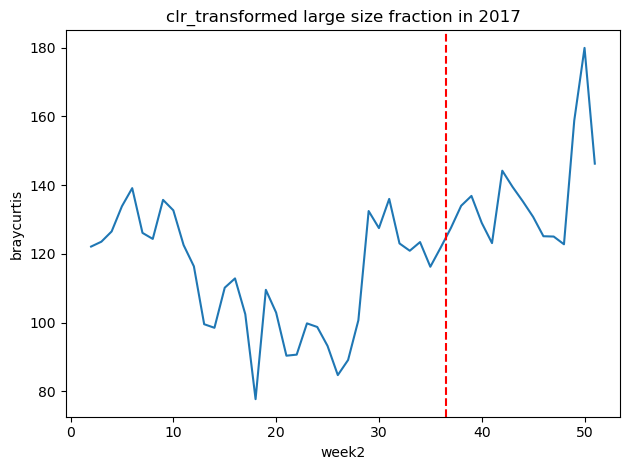

In [270]:
#plot the consecutive distances
sns.lineplot(data=dist_consecutive, x="week2", y="distance", markers=True)
plt.title('clr_transformed large size fraction in 2017')
plt.tight_layout()
plt.axvline(x=36.5, color='r', linestyle='--')
plt.show()

In [ ]:
taxonomic_bar_plot_by_week_no_other

In [403]:
df_y['weekn'] = pd.to_numeric(df_y['weekn'])
df_yW = df_y[df_y['weekn'] > 25 ]

In [406]:
fig = taxo_barplot(df_yW, tax_level='Genus', topn=300, order='least', 
                   abundance_col='feature_frequency', week_col='weekn')
fig.show()

In [339]:
crt_table = identify_CRT(df_y, feature_col='feature_id', 
                         abundance_col='ratio', bloom_threshold=0.0025, filter_crt=True)

print(crt_table)

fig = px.scatter(crt_table, 
                 x='avg_feature_frequency', 
                 y='max_feature_frequency',
                 size='bloom_count', 
                 hover_data=['feature_id'],

fig.show()


                            feature_id  avg_feature_frequency  max_feature_frequency  bloom_count
12    012054e3f62502aff7f455e1592ea87f               0.001057               0.002782            1
13    0129f982224a5b1bca12f2ffe6a7d845               0.001022               0.005814            1
18    0180392035a98ecc99efc2bc4839136c               0.001391               0.005766            3
19    0184b0e8cdfb040dfd7e1d74c2cdc76e               0.001266               0.003022            1
22    01b6055d816dfa26f1049780d85de084               0.001617               0.007592            3
...                                ...                    ...                    ...          ...
3876  fcf11ec8b80994412cebcb3c12ac3d58               0.002325               0.002700            1
3908  fe980881c8f03bec356a75c8186100ae               0.001045               0.004616            4
3918  ff1bd8113a59e63cbb44713fe3645ed6               0.001789               0.006271            6
3928  ff85d0744f1137

In [431]:
fig = plot_crt(df_y, feature_col='feature_id', 
               abundance_col='ratio', week_col='weekn', bloom_threshold=0.0035)
fig.show()

In [394]:
plotemp = bbmp_updated[['year', 'weekn', 'Temperature_BIO_bbmp', 'depth']]

In [397]:
plotemp = plotemp[plotemp['depth'] == 1]
plotemp = plotemp[plotemp['weekn'] > 30]
#plotemp = plotemp[plotemp['year'] == 2019]
plotemp['year'] = plotemp.year.astype(str)

<AxesSubplot: xlabel='weekn', ylabel='Temperature_BIO_bbmp'>

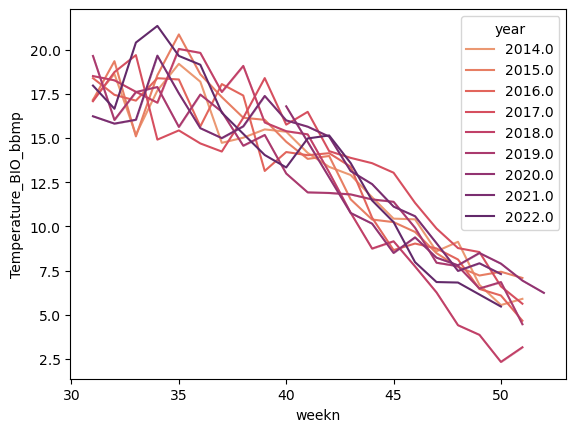

In [398]:
sns.lineplot(data=plotemp, x="weekn", y="Temperature_BIO_bbmp", hue="year", palette="flare")

In [400]:
fig = px.line(plotemp, x="weekn", y="Temperature_BIO_bbmp", color='year')
fig.show()
#in year 2019 -- big drop in temperature (earlier than usual at week 41)

In [17]:
data = newseparated[newseparated['year'] == 2019]
data = data[data['weekn'] >32]
data = data[data['weekn'] <45]

In [18]:
figs = taxbarplot_by_year(comm="mycomm", table=data, level="Family", depth=5, topn=15, include_other=False)

Find candidate events:
Determine the magnitude environmental shift
Duration:
Community level effect: (high, moderate, low)

What is our main question + subquestions?

In [74]:
def repeat_rarefy_df(df, sampling_depth: int, repeat_times: int, with_replacement: bool = True, random_state: int = None) -> pd.DataFrame:

    df_wide = df.pivot_table(index='sampleid', columns='feature_id', 
                             values='feature_frequency', fill_value=0)

    sample_totals = df_wide.sum(axis=1)


    samples_to_keep = sample_totals[sample_totals >= sampling_depth].index
    df_wide_filtered = df_wide.loc[samples_to_keep]

    print(f"Removed {df_wide.shape[0] - df_wide_filtered.shape[0]} samples from {df_wide.shape[0]} below the rarefaction depth of {sampling_depth}.")

    if random_state is not None:
        np.random.seed(random_state)
    
    # Check that each sample has enough counts to be rarefied.
    sample_totals = df_wide_filtered.sum(axis=1)
    if (sample_totals < sampling_depth).any():
        missing = sample_totals[sample_totals < sampling_depth]
        raise ValueError(f"Some samples have total counts below the sampling depth:\n{missing}")
    
    # Prepare to store each replicate's rarefied DataFrame.
    replicate_list = []
    
    # For each replicate, rarefy each sample.
    for rep in range(repeat_times):
        rarefied_rows = {}
        for sample in df_wide_filtered.index:
            counts = df_wide_filtered.loc[sample].values
            total = counts.sum()
            # Compute the relative proportions.
            proportions = counts / total
            
            # For now, we'll use np.random.multinomial which simulates sampling with replacement.
            # (If with_replacement=False, a different approach would be needed.)
            rarefied = np.random.multinomial(sampling_depth, proportions)
            rarefied_rows[sample] = rarefied
        rep_df = pd.DataFrame.from_dict(rarefied_rows, orient='index', columns=df_wide_filtered.columns)
        replicate_list.append(rep_df)
    
    # Average the replicate rarefied DataFrames.
    mean_rarefied = sum(replicate_list) / repeat_times
    # Apply ceiling to get integer counts.
    mean_rarefied = np.ceil(mean_rarefied).astype(int)
    
    return mean_rarefied

# Example usage:
# Assume df_counts is your DataFrame (samples as rows, features as columns)
# For example, if you want a rarefaction depth of 20,000 reads and 100 repeats:
# rarefied_df = repeat_rarefy_df(df_counts, sampling_depth=20000, repeat_times=100, random_state=42)
# print(rarefied_df)


In [ ]:
from joblib import Parallel, delayed

def rarefy_sample(counts, depth, random_state=None):
    """
    Rarefy a single sample using multinomial sampling.
    """
    if random_state is not None:
        np.random.seed(random_state)
    total = counts.sum()
    if total < depth:
        raise ValueError("Total counts in the sample is lower than the rarefaction depth.")
    proportions = counts / total
    return np.random.multinomial(n=depth, pvals=proportions)

def rarefy_replicate(df_wide, sampling_depth, rep_idx, random_state_base=None):
    """
    Compute one replicate rarefaction for the whole DataFrame.
    random_state_base is used to vary the random seed for each replicate.
    """
    rarefied_rows = {}
    # Optional: change the random state for each replicate if random_state_base is provided.
    seed = (random_state_base + rep_idx) if random_state_base is not None else None
    for sample in df_wide.index:
        counts = df_wide.loc[sample].values
        rarefied_rows[sample] = rarefy_sample(counts, sampling_depth, random_state=seed)
    rep_df = pd.DataFrame.from_dict(rarefied_rows, orient='index', columns=df_wide.columns)
    return rep_df

def repeat_rarefy_parallel(df_wide, sampling_depth: int, repeat_times: int, 
                           random_state: int = None, n_jobs: int = -1) -> pd.DataFrame:
    """
    Perform repeat-rarefaction in parallel on a samples x features DataFrame.
    
    Parameters:
      df_wide: pandas DataFrame of counts (samples as rows, features as columns).
      sampling_depth: rarefaction depth (must be <= total counts in each sample).
      repeat_times: number of rarefaction replicates.
      random_state: optional random seed base.
      n_jobs: number of parallel jobs to run (-1 uses all available cores).
      
    Returns:
      A DataFrame of the average rarefied counts across replicates.
    """
    # First, verify that all samples have enough counts.
    sample_totals = df_wide.sum(axis=1)
    if (sample_totals < sampling_depth).any():
        missing = sample_totals[sample_totals < sampling_depth]
        raise ValueError(f"Some samples have total counts below the sampling depth:\n{missing}")

    # Run each replicate in parallel
    replicates = Parallel(n_jobs=n_jobs)(
        delayed(rarefy_replicate)(df_wide, sampling_depth, rep_idx, random_state)
        for rep_idx in range(repeat_times)
    )
    
    # Average the replicates
    mean_rarefied = sum(replicates) / repeat_times
    # Apply ceiling to get integer counts (if desired)
    mean_rarefied = np.ceil(mean_rarefied).astype(int)
    
    return mean_rarefied

# Example usage:
# Assume df_wide is your DataFrame (samples as rows, features as columns)
# For instance, with a rarefaction depth of 20000 and 100 replicates:
# rarefied_df = repeat_rarefy_parallel(df_wide, sampling_depth=20000, repeat_times=100, random_state=42, n_jobs=-1)
# print(rarefied_df)